In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cars_raw_messy.csv")

In [3]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,torque,seats,selling_price
0,Maruti Vitara,Maruti,Vitara,2,30000,individual,diesel,Manual,24.3 kmpl,1248 CC,88.5 bhp,91Nm@ 3500rpm,5.0,850000
1,Tata Nexon,Tata,Nexon,3,4200,Individual,Petrol,Manual,17.0 kmpl,1198 CC,108.5 bhp,190Nm@ 2000rpm,5.0,755000
2,Hyundai Verna,Hyundai,Verna,12,55000,DEALER,Petrol,Manual,NaN,1599 CC,103.2 bhp,113Nm@ 4000rpm,5.0,250000
3,Volkswagen Polo,Volkswagen,Polo,8,35000,individual,petrol,Manual,NaN,NaN,73.9 bhp,NaN,5.0,335000
4,Maruti Celerio,Maruti,Celerio,3,5000,individual,PETROL,Automatic,23.1 kmpl,998 CC,67.04 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,475000


In [4]:
df.shape

(8250, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8250 entries, 0 to 8249
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           8250 non-null   object 
 1   brand              8250 non-null   object 
 2   model              8250 non-null   object 
 3   vehicle_age        8250 non-null   int64  
 4   km_driven          8250 non-null   int64  
 5   seller_type        8250 non-null   object 
 6   fuel_type          8250 non-null   object 
 7   transmission_type  8250 non-null   object 
 8   mileage            7680 non-null   object 
 9   engine             8000 non-null   object 
 10  max_power          7840 non-null   object 
 11  torque             7749 non-null   object 
 12  seats              8004 non-null   float64
 13  selling_price      8250 non-null   int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 902.5+ KB


In [6]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,570
engine,250


In [7]:
df.duplicated().sum()

np.int64(250)

In [8]:
df = df.drop_duplicates()

In [9]:
df = df.reset_index(drop=True)

In [10]:
print("Duplicated Rows Number:", df.duplicated().sum())


Duplicated Rows Number: 0


In [11]:
print("Rows Number Ater Removing Duplicated :", df.shape[0])

Rows Number Ater Removing Duplicated : 8000


In [12]:
df['mileage'] = df['mileage'].str.split(' ').str[0]

In [13]:
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

In [14]:
df['engine'] = df['engine'].str.split(' ').str[0]
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')

In [15]:
df['max_power'] = df['max_power'].str.split(' ').str[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [16]:
df[['mileage','engine','max_power']].head()

,mileage,engine,max_power
0,24.3,1248.0,88.50
1,17.0,1198.0,108.50
2,NaN,1599.0,103.20
3,NaN,NaN,73.90
4,23.1,998.0,67.04


In [17]:
df['torque'] = df['torque'].str.extract(r'(\d+\.?\d*)')
df['torque'] = pd.to_numeric(df['torque'], errors='coerce')
df['torque'].head(10)

,torque
0,91.0
1,190.0
2,113.0
3,NaN
4,12.7
5,170.0
6,24.0
7,190.0
8,200.0
9,200.0


In [18]:
df['engine'] = df['engine'].fillna(df['engine'].median())

In [19]:
df['max_power'] = df['max_power'].fillna(df['max_power'].median())

In [20]:
df['torque'] = df['torque'].fillna(df['torque'].median())

In [21]:
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])


In [22]:
print("Missing vaue after processing :")
print(df.isnull().sum())

Missing vaue after processing :
car_name               0
brand                  0
model                  0
vehicle_age            0
km_driven              0
seller_type            0
fuel_type              0
transmission_type      0
mileage              320
engine                 0
max_power              0
torque                 0
seats                  0
selling_price          0
dtype: int64


In [23]:
print(" Mileage Type:", df['mileage'].dtype)

 Mileage Type: float64


In [24]:
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

In [25]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())

In [26]:
print(df.isnull().sum())

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
torque               0
seats                0
selling_price        0
dtype: int64


In [27]:
df['seller_type'] = df['seller_type'].str.strip().str.title()


In [28]:
df['fuel_type'] = df['fuel_type'].str.strip().str.title()

In [29]:
print("seller_type After Strip  : ")
print(df['seller_type'].value_counts())
print("\nfuel_type After Strip  :")
print(df['fuel_type'].value_counts())

seller_type After Strip  : 
seller_type
Dealer              4890
Individual          3019
Trustmark Dealer      91
Name: count, dtype: int64

fuel_type After Strip  :
fuel_type
Petrol      3979
Diesel      3836
Cng          155
Lpg           27
Electric       3
Name: count, dtype: int64


In [30]:
# نصدّر الداتا النضيفة كملف Excel
df.to_excel("cars_cleaned.xlsx", index=False)

# نصدّرها كمان CSV (احتياطي)
df.to_csv("cars_cleaned.csv", index=False)

print("Cleaned Data !")
print(" Rows Number :", df.shape[0], "| Columns Number  :", df.shape[1])

✅ اتصدّرت الداتا النضيفة!
عدد الصفوف: 8000 | عدد الأعمدة: 14


In [31]:
y = df['selling_price']

In [32]:
X = df.drop(columns=['selling_price', 'car_name', 'model'])

In [33]:
print(" X Coulmns  :")
print(X.columns.tolist())
print("\ Number Rwos & Culomns of    X:", X.shape)
print("\n Frist 3 Rows of  X:")
print(X.head(3))

 X Coulmns  :
['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'torque', 'seats']
\ Number Rwos & Culomns of    X: (8000, 11)

 Frist 3 Rows of  X:
     brand  vehicle_age  km_driven seller_type fuel_type transmission_type  \
0   Maruti            2      30000  Individual    Diesel            Manual   
1     Tata            3       4200  Individual    Petrol            Manual   
2  Hyundai           12      55000      Dealer    Petrol            Manual   

   mileage  engine  max_power  torque  seats  
0    24.30  1248.0       88.5    91.0    5.0  
1    17.00  1198.0      108.5   190.0    5.0  
2    19.62  1599.0      103.2   113.0    5.0  


<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_502/2000279510.py:3: SyntaxWarning: invalid escape sequence '\ '
  print("\ Number Rwos & Culomns of    X:", X.shape)


In [34]:
X = pd.get_dummies(X, drop_first=True)


In [35]:
print("Nmber of Culmnos After Transamition :", X.shape[1])
print("\n New Coulmns Name:")
print(X.columns.tolist())
print("\n First 3 Rows ")
print(X.head(3))

Nmber of Culmnos After Transamition : 40

 New Coulmns Name:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'brand_BMW', 'brand_Datsun', 'brand_Force', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land Rover', 'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-AMG', 'brand_Mercedes-Benz', 'brand_Mini', 'brand_Nissan', 'brand_Porsche', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_Lpg', 'fuel_type_Petrol', 'transmission_type_Manual']

 First 3 Rows 
   vehicle_age  km_driven  mileage  engine  max_power  torque  seats  \
0            2      30000    24.30  1248.0       88.5    91.0    5.0   
1            3       4200    17.00  1198.0      108.5   190.0    5.0   
2           12      55000    19.62  1599.0

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
print(" Train:", X_train.shape[0], "Cars")
print("Test:", X_test.shape[0], "Cars")

 Train: 6400 Cars
Test: 1600 Cars


In [39]:

from sklearn.linear_model import LinearRegression



In [40]:

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

In [42]:
y_pred = model.predict(X_test)

In [43]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", round(r2, 3))

R² Score: 0.756


In [44]:
mae = mean_absolute_error(y_test, y_pred)
print("(MAE):", round(mae))

(MAE): 201156


In [47]:

from sklearn.ensemble import RandomForestRegressor


In [48]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)

print("=== Random Forest ===")
print("R² Score:", round(r2_rf, 3))
print("MAE:", round(mae_rf))

=== Random Forest ===
R² Score: 0.928
MAE: 100665


In [49]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

In [50]:
print(" Best 10 Fetuers Effected On Price :")
print(importances.head(10).to_string(index=False))

 Best 10 Fetuers Effected On Price :
                 Feature  Importance
               max_power    0.638373
             vehicle_age    0.149068
               km_driven    0.055133
                  engine    0.047995
                 mileage    0.031509
        brand_Land Rover    0.016668
     brand_Mercedes-Benz    0.012407
                  torque    0.009416
transmission_type_Manual    0.007927
               brand_BMW    0.006016


In [51]:

from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

print("=== Comparision Betwen Models ===\n")
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    print(f"{name}:")
    print(f"   R² Score = {round(r2, 3)}")
    print(f"   MAE = {round(mae)} \n")

=== Comparision Betwen Models ===

Random Forest:
   R² Score = 0.928
   MAE = 100665 

Gradient Boosting:
   R² Score = 0.901
   MAE = 122208 

XGBoost:
   R² Score = 0.92
   MAE = 100930 



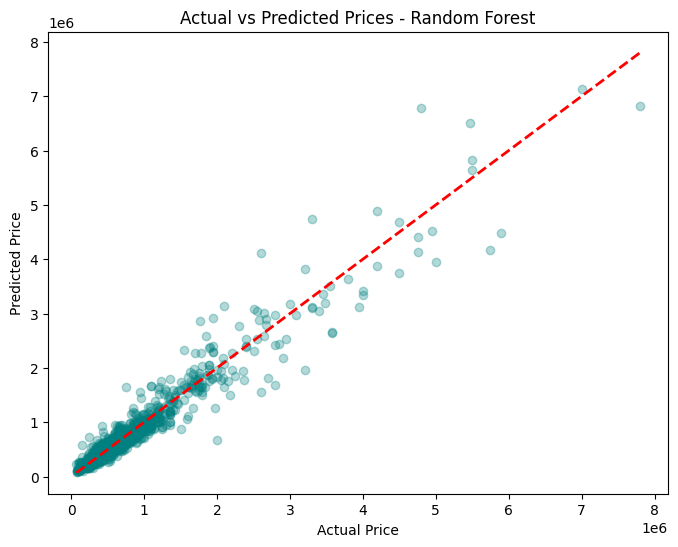

In [52]:
import matplotlib.pyplot as plt


rf_pred = rf_model.predict(X_test)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.3, color='teal')


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Random Forest")
plt.show()

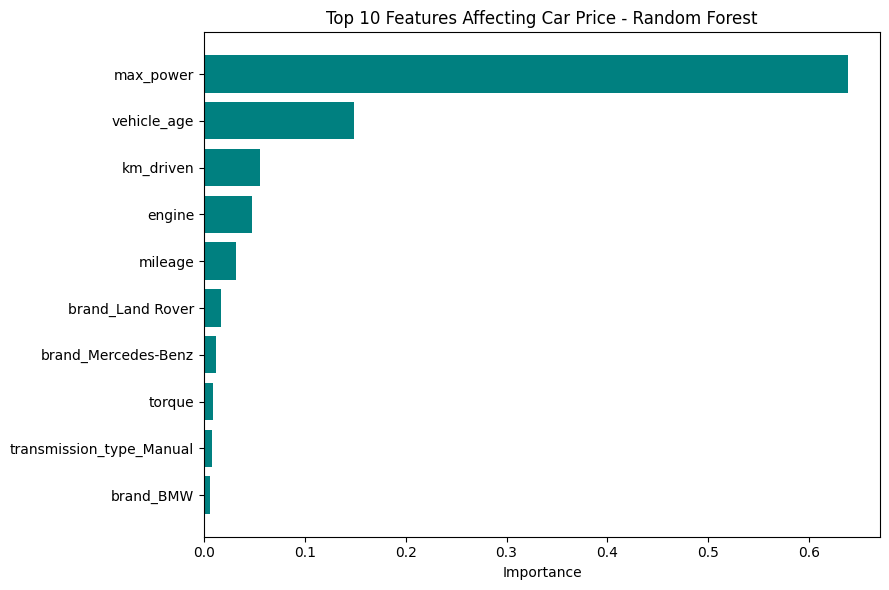

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Get top 10 most important features
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

# Plot horizontal bar chart
plt.figure(figsize=(9, 6))
plt.barh(importances['Feature'], importances['Importance'], color='teal')
plt.xlabel("Importance")
plt.title("Top 10 Features Affecting Car Price - Random Forest")
plt.gca().invert_yaxis()   # most important on top
plt.tight_layout()
plt.show()

In [54]:
# ===== Predict price for a new car =====

# Enter the car specs here (change values as you like!)
new_car = {
    'vehicle_age': 5,
    'km_driven': 50000,
    'mileage': 20.0,
    'engine': 1200,
    'max_power': 85.0,
    'torque': 110.0,
    'seats': 5,
    'brand': 'Maruti',
    'fuel_type': 'Petrol',
    'transmission_type': 'Manual',
    'seller_type': 'Dealer'
}

# Convert to DataFrame
new_df = pd.DataFrame([new_car])

# One-Hot Encoding (same as training data)
new_df = pd.get_dummies(new_df)

# Align columns to match training features exactly
new_df = new_df.reindex(columns=X.columns, fill_value=0)

# Predict the price
predicted_price = rf_model.predict(new_df)

print("Car specs:", new_car['brand'], "|", new_car['vehicle_age'], "years |", new_car['fuel_type'])
print("Predicted Price:", round(predicted_price[0]), "INR")

Car specs: Maruti | 5 years | Petrol
Predicted Price: 480860 INR


In [55]:
new_car = {
    'vehicle_age': 2,
    'km_driven': 20000,
    'mileage': 15.0,
    'engine': 3000,
    'max_power': 250.0,
    'torque': 400.0,
    'seats': 5,
    'brand': 'BMW',
    'fuel_type': 'Diesel',
    'transmission_type': 'Automatic',
    'seller_type': 'Dealer'
}

new_df = pd.DataFrame([new_car])
new_df = pd.get_dummies(new_df)
new_df = new_df.reindex(columns=X.columns, fill_value=0)

predicted_price = rf_model.predict(new_df)

print("Car specs:", new_car['brand'], "|", new_car['vehicle_age'], "years |", new_car['fuel_type'])
print("Predicted Price:", round(predicted_price[0]), "INR")

Car specs: BMW | 2 years | Diesel
Predicted Price: 5742090 INR


In [56]:
import joblib

# Save the trained model to a file
joblib.dump(rf_model, 'car_price_model.pkl')

# Also save the feature columns (needed for future predictions)
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Model saved successfully!")

Model saved successfully!
